# Exploratory Data Analysis

## Overview

This notebook explores the cleaned Olist E-commerce dataset to answer key business questions through descriptive statistics and visualizations.

The findings from this notebook will be used to build an interactive Power BI dashboard.

# Exploratory Data Analysis

## Overview

This notebook explores the cleaned Olist E-commerce dataset to answer key business questions through descriptive statistics and visualizations.

The findings from this notebook will be used to build an interactive Power BI dashboard.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("ggplot")

In [3]:
sales = pd.read_csv("../data/processed/sales_clean.csv")

sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,purchase_year,purchase_month,purchase_day,delivery_days,total_sales
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,2017,October,Monday,8.0,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,2017,October,Monday,8.0,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,2017,October,Monday,8.0,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,2018-08-08,2018-08-08 18:37:50,31570.0,belo horizonte,SP,2018,July,Tuesday,13.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,2018-08-18,2018-08-22 19:07:58,14840.0,guariba,SP,2018,August,Wednesday,9.0,179.12


In [4]:
sales.shape

(119143, 45)

In [5]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 45 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [6]:
total_sales = sales["total_sales"].sum()

total_orders = sales["order_id"].nunique()

total_customers = sales["customer_unique_id"].nunique()

average_order_value = (
    total_sales / total_orders
)

average_delivery = sales["delivery_days"].mean()

In [7]:
summary = pd.DataFrame({

    "Metric":[

        "Total Sales",

        "Total Orders",

        "Total Customers",

        "Average Order Value",

        "Average Delivery Days"

    ],

    "Value":[

        total_sales,

        total_orders,

        total_customers,

        average_order_value,

        average_delivery

    ]

})

summary

,Metric,Value
0,Total Sales,1.664373e+07
1,Total Orders,9.944100e+04
2,Total Customers,9.609600e+04
3,Average Order Value,1.673729e+02
4,Average Delivery Days,1.202259e+01


Business Question 1
Which product categories generate the highest revenue?

In [8]:
category_sales = (
    sales.groupby("product_category_name_english")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [12]:
total_revenue = sales["total_sales"].sum()

category_summary = (
    category_sales.reset_index()
)

category_summary["Contribution (%)"] = (
    category_summary["total_sales"] / total_revenue * 100
).round(2)

category_summary.rename(
    columns={
        "product_category_name_english": "Category",
        "total_sales": "Revenue"
    },
    inplace=True
)

category_summary

,Category,Revenue,Contribution (%)
0,health_beauty,1491397.76,8.96
1,watches_gifts,1358845.59,8.16
2,bed_bath_table,1327662.02,7.98
3,sports_leisure,1205197.85,7.24
4,computers_accessories,1104362.03,6.64
5,furniture_decor,955367.22,5.74
6,housewares,823623.50,4.95
7,cool_stuff,752702.21,4.52
8,auto,714431.95,4.29
9,garden_tools,625387.31,3.76


In [13]:
top5 = category_summary.head(5)["Contribution (%)"].sum()

print(f"Top 5 Contribution : {top5:.2f}%")

Top 5 Contribution : 38.98%


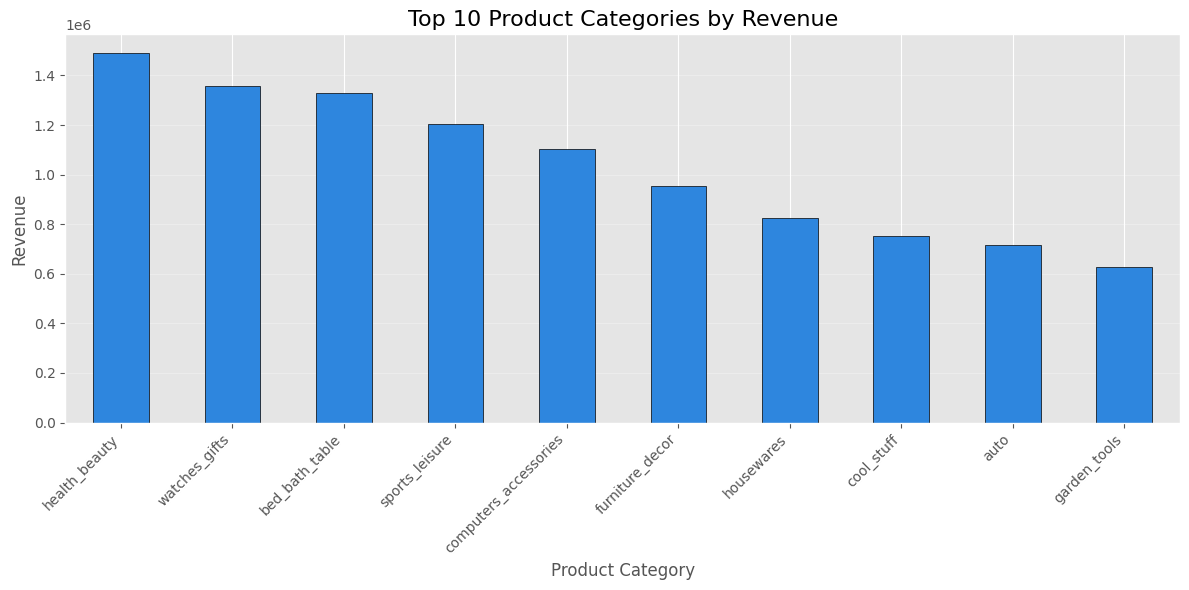

In [14]:
plt.figure(figsize=(12,6))

category_sales.plot(
    kind="bar",
    color="#2E86DE",
    edgecolor="black"
)

plt.title("Top 10 Product Categories by Revenue", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

The highest revenue com### Business Insight

The **Health & Beauty** category is the largest revenue contributor, generating **1,491,398** in sales and contributing **8.96%** of the total revenue.

It is followed by:

| Rank | Category | Revenue | Contribution |
|-----:|-------------------------|-------------:|-------------:|
| 1 | Health & Beauty | 1,491,398 | 8.96% |
| 2 | Watches & Gifts | 1,358,846 | 8.16% |
| 3 | Bed Bath Table | 1,327,662 | 7.98% |
| 4 | Sports & Leisure | 1,205,198 | 7.24% |
| 5 | Computers & Accessories | 1,104,362 | 6.64% |w

Together, the **top five product categories contribute nearly 39% of the total revenue**, indicating that customer demand is highly concentrated in health, lifestyle, home, and technology-related products.

### Business Recommendation

- Prioritize inventory planning for the top-performing categories to minimize stock shortages.
- Allocate larger marketing budgets to these categories, particularly during promotional campaigns and seasonal events.
- Conduct further analysis on lower-performing categories such as **Auto** and **Garden Tools** to identify opportunities for growth through pricing strategies, product assortment, or targeted promotions.es from ...

In [10]:
city = (
    sales.groupby("customer_city")
    ["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

# Business Question 2

## Which cities have the highest number of customers?

Understanding customer distribution helps identify major markets and prioritize sales, logistics, and marketing strategies.

In [15]:
city_customers = (
    sales.groupby("customer_city")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

In [16]:
city_summary = city_customers.reset_index()

city_summary.columns = [
    "City",
    "Number of Customers"
]

city_summary

,City,Number of Customers
0,sao paulo,14984
1,rio de janeiro,6620
2,belo horizonte,2672
3,brasilia,2069
4,curitiba,1465
5,campinas,1398
6,porto alegre,1326
7,salvador,1209
8,guarulhos,1153
9,sao bernardo do campo,908


In [17]:
total_customer = sales["customer_unique_id"].nunique()

city_summary["Contribution (%)"] = (
    city_summary["Number of Customers"]
    / total_customer
    *100
).round(2)

city_summary

,City,Number of Customers,Contribution (%)
0,sao paulo,14984,15.59
1,rio de janeiro,6620,6.89
2,belo horizonte,2672,2.78
3,brasilia,2069,2.15
4,curitiba,1465,1.52
5,campinas,1398,1.45
6,porto alegre,1326,1.38
7,salvador,1209,1.26
8,guarulhos,1153,1.20
9,sao bernardo do campo,908,0.94


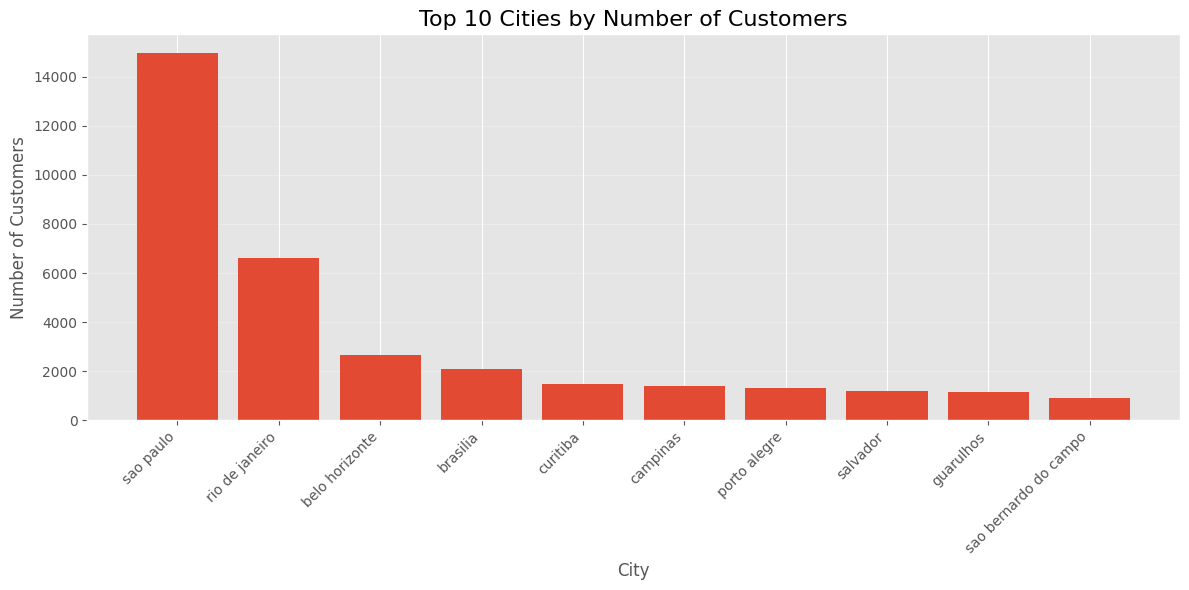

In [18]:
plt.figure(figsize=(12,6))

plt.bar(
    city_summary["City"],
    city_summary["Number of Customers"]
)

plt.title(
    "Top 10 Cities by Number of Customers",
    fontsize=16
)

plt.xlabel("City")

plt.ylabel("Number of Customers")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [20]:
city_summary.style.hide(axis="index")

City,Number of Customers,Contribution (%)
sao paulo,14984,15.590000
rio de janeiro,6620,6.890000
belo horizonte,2672,2.780000
brasilia,2069,2.150000
curitiba,1465,1.520000
campinas,1398,1.450000
porto alegre,1326,1.380000
salvador,1209,1.260000
guarulhos,1153,1.200000
sao bernardo do campo,908,0.940000


In [21]:
top10_customer = city_summary["Contribution (%)"].sum()

print(f"Top 10 Cities Contribution : {top10_customer:.2f}%")

Top 10 Cities Contribution : 35.16%


### Business Insight

The customer distribution analysis shows that **São Paulo** is the company's largest market, with **14,984 unique customers**, accounting for **15.59%** of the total customer base.

**Rio de Janeiro** ranks second with **6,620 customers (6.89%)**, followed by **Belo Horizonte** with **2,672 customers (2.78%)**. The significant gap between São Paulo and the remaining cities indicates that customer acquisition is highly concentrated in Brazil's largest metropolitan area.

Overall, the **top 10 cities contribute 35.16% of all customers**, meaning that more than one-third of the company's customers are concentrated in only ten cities. This suggests that urban regions are the primary drivers of the company's customer base and overall sales performance.

### Business Recommendation

Based on the customer distribution analysis, the following recommendations are proposed:

- **Strengthen customer retention** in São Paulo through loyalty programs, personalized promotions, and exclusive offers, as it represents the company's largest customer market.

- **Improve logistics and fulfillment operations** in São Paulo and Rio de Janeiro to maintain customer satisfaction and support high order volumes.

- **Expand marketing campaigns** in medium-sized cities such as Belo Horizonte, Brasília, Curitiba, and Campinas, where customer growth potential remains significant.

- **Increase market penetration** in lower-contributing cities through targeted digital advertising, localized promotions, and strategic partnerships to diversify the customer base and reduce dependence on major metropolitan areas.

# Business Question 3

## During which months does the company achieve the highest sales?

In [27]:
sales[
    [
        "purchase_year",
        "purchase_month",
        "total_sales"
    ]
].head()

,purchase_year,purchase_month,total_sales
0,2017,October,38.71
1,2017,October,38.71
2,2017,October,38.71
3,2018,July,141.46
4,2018,August,179.12


In [28]:
sales["purchase_month_num"] = pd.to_datetime(
    sales["order_purchase_timestamp"]
).dt.month

In [29]:
sales[
    [
        "purchase_month_num",
        "purchase_month"
    ]
].head()

,purchase_month_num,purchase_month
0,10,October
1,10,October
2,10,October
3,7,July
4,8,August


In [30]:
monthly_sales = (
    sales.groupby(
        [
            "purchase_month_num",
            "purchase_month"
        ]
    )["total_sales"]
    .sum()
    .reset_index()
    .sort_values("purchase_month_num")
)

monthly_sales

,purchase_month_num,purchase_month,total_sales
0,1,January,1306772.95
1,2,February,1342659.96
2,3,March,1668858.94
3,4,April,1650810.02
4,5,May,1827967.20
5,6,June,1606805.50
6,7,July,1729281.11
7,8,August,1744564.69
8,9,September,767846.91
9,10,October,867642.18


In [31]:
total_revenue = monthly_sales["total_sales"].sum()

monthly_sales["Contribution (%)"] = (
    monthly_sales["total_sales"]
    / total_revenue
    *100
).round(2)

monthly_sales.rename(
    columns={
        "purchase_month": "Month",
        "total_sales": "Revenue"
    },
    inplace=True
)

monthly_sales

,purchase_month_num,Month,Revenue,Contribution (%)
0,1,January,1306772.95,7.85
1,2,February,1342659.96,8.07
2,3,March,1668858.94,10.03
3,4,April,1650810.02,9.92
4,5,May,1827967.20,10.98
5,6,June,1606805.50,9.65
6,7,July,1729281.11,10.39
7,8,August,1744564.69,10.48
8,9,September,767846.91,4.61
9,10,October,867642.18,5.21


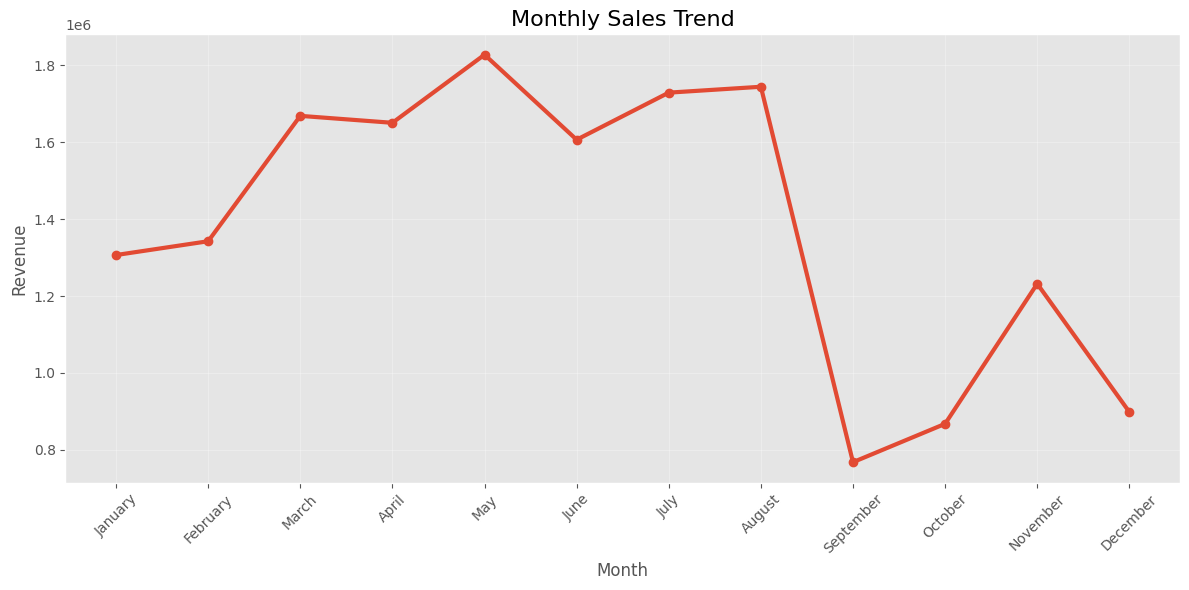

In [32]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Revenue"],
    marker="o",
    linewidth=3
)

plt.title(
    "Monthly Sales Trend",
    fontsize=16
)

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [33]:
monthly_sales.sort_values(
    "Revenue",
    ascending=False
)

,purchase_month_num,Month,Revenue,Contribution (%)
4,5,May,1827967.20,10.98
7,8,August,1744564.69,10.48
6,7,July,1729281.11,10.39
2,3,March,1668858.94,10.03
3,4,April,1650810.02,9.92
5,6,June,1606805.50,9.65
1,2,February,1342659.96,8.07
0,1,January,1306772.95,7.85
10,11,November,1232074.30,7.40
11,12,December,898447.54,5.40


### Business Insight

The monthly sales analysis reveals that **May** recorded the highest revenue, generating **1.83 million** in sales and contributing **10.98%** of the total annual revenue.

High sales performance was also observed during **August (10.48%)**, **July (10.39%)**, and **March (10.03%)**, indicating a consistently strong sales period during the middle of the year.

In contrast, **September** generated the lowest revenue at only **767,847 (4.61%)**, followed by **October (5.21%)** and **December (5.40%)**.

Overall, sales gradually increased from January to May, remained relatively strong through August, then experienced a significant decline in September before partially recovering in November.

This pattern suggests that customer purchasing behavior may be influenced by seasonal demand or promotional activities during specific periods of the year.

### Business Recommendation

Based on the monthly sales trend, the following recommendations are proposed:

- Increase inventory levels before the high-demand months, particularly from **March to August**, to prevent stock shortages.

- Schedule major promotional campaigns and marketing activities ahead of the strongest sales period to maximize revenue.

- Investigate the sharp decline in **September** to identify possible causes such as reduced promotional activities, seasonal demand changes, or operational issues.

- Develop targeted campaigns during lower-performing months (September, October, and December) to stabilize monthly revenue throughout the year.

- Use the identified sales pattern to improve demand forecasting and resource allocation for future business planning.

In [34]:
sales["year_month"] = (
    pd.to_datetime(sales["order_purchase_timestamp"])
    .dt.to_period("M")
    .astype(str)
)

In [35]:
monthly_trend = (
    sales.groupby("year_month")["total_sales"]
    .sum()
    .reset_index()
)

monthly_trend

,year_month,total_sales
0,2016-09,354.75
1,2016-10,58730.85
2,2016-12,19.62
3,2017-01,148030.11
4,2017-02,303648.31
5,2017-03,459778.64
6,2017-04,449707.81
7,2017-05,634762.22
8,2017-06,531052.06
9,2017-07,631341.57


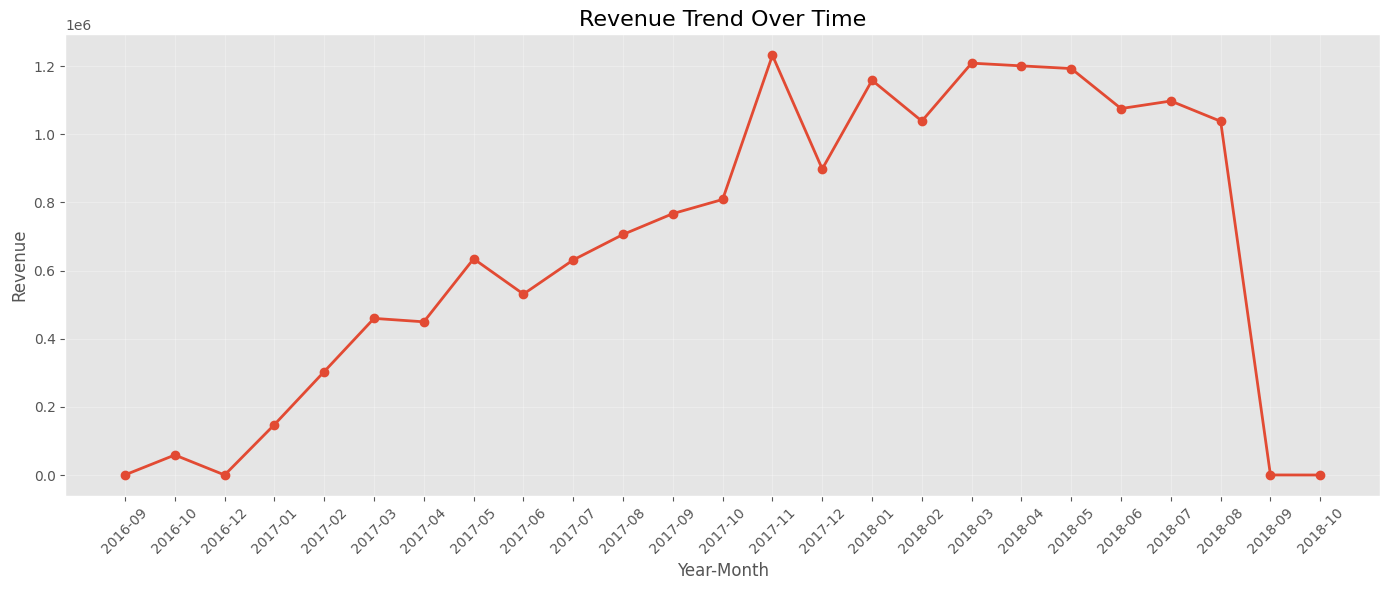

In [36]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_trend["year_month"],
    monthly_trend["total_sales"],
    marker="o",
    linewidth=2
)

plt.title(
    "Revenue Trend Over Time",
    fontsize=16
)

plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [37]:
monthly_trend.sort_values(
    "total_sales",
    ascending=False
).head()

,year_month,total_sales
13,2017-11,1232074.30
17,2018-03,1209080.30
18,2018-04,1201102.21
19,2018-05,1193204.98
15,2018-01,1158742.84


In [38]:
monthly_trend.sort_values(
    "total_sales"
).head()

,year_month,total_sales
24,2018-10,0.00
2,2016-12,19.62
23,2018-09,166.46
0,2016-09,354.75
1,2016-10,58730.85


In [39]:
sales[
    sales["year_month"] == "2018-10"
][
    [
        "order_id",
        "price",
        "freight_value",
        "total_sales"
    ]
].head(20)

,order_id,price,freight_value,total_sales
38270,a2ac6dad85cf8af5b0afb510a240fe8c,NaN,NaN,NaN
72820,10a045cdf6a5650c21e9cfeb60384c16,NaN,NaN,NaN
81748,b059ee4de278302d550a3035c4cdb740,NaN,NaN,NaN
105869,616fa7d4871b87832197b2a137a115d2,NaN,NaN,NaN


In [40]:
sales[
    sales["year_month"] == "2018-09"
].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_zip_code_prefix,seller_city,seller_state,purchase_year,purchase_month,purchase_day,delivery_days,total_sales,purchase_month_num,year_month
2142,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17,08642cd329066fe11ec63293f714f2f8,33030,...,NaN,NaN,NaN,2018,September,Thursday,NaN,NaN,9,2018-09
6084,ea844c92cf978ea23321fa7fe5871761,6ddc45ad08e6a2c885ca2255fc52d6df,canceled,2018-09-13 09:56:12,NaN,NaN,NaN,2018-09-27,c1ee153508c6b785b491443a95ff364e,89300,...,NaN,NaN,NaN,2018,September,Thursday,NaN,NaN,9,2018-09
11889,87ae60ef8b08ae0e5f903cacb53a6904,fea4d57ed3a45455f89c25ef3dae8ee8,canceled,2018-09-11 16:45:54,NaN,NaN,NaN,2018-09-26,09687a7b7431a93b5c53b50ba779bf94,12010,...,NaN,NaN,NaN,2018,September,Tuesday,NaN,NaN,9,2018-09
19512,bd35b677fd239386e9861d11ae98ab56,ad2eb5d02c0808bcd8743117f6383cf6,canceled,2018-09-17 17:21:16,NaN,NaN,NaN,2018-10-01,ef0103e9602d12594d19c2b666219bc1,30810,...,NaN,NaN,NaN,2018,September,Monday,NaN,NaN,9,2018-09
24849,4d59cc2a2e7bb6c0a851725f5888a9b5,ead83a4f8f7be8c3034b2e98754a6147,canceled,2018-09-06 14:50:07,NaN,NaN,NaN,2018-09-21,230a1e9f42924d41f37fd22a1d4a9707,6540,...,NaN,NaN,NaN,2018,September,Thursday,NaN,NaN,9,2018-09


In [41]:
sales.groupby("year_month")["order_id"].nunique()

year_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Name: order_id, dtype: int64

In [42]:
sales_completed = sales[
    (sales["order_status"] == "delivered") &
    (sales["total_sales"].notna())
].copy()

In [43]:
monthly_trend = (
    sales_completed
    .groupby("year_month")["total_sales"]
    .sum()
    .reset_index()
)

In [44]:
# Semua data (untuk customer, status, dll.)
sales

# Hanya transaksi berhasil (untuk revenue)
sales_completed = sales[
    (sales["order_status"] == "delivered") &
    (sales["total_sales"].notna())
].copy()

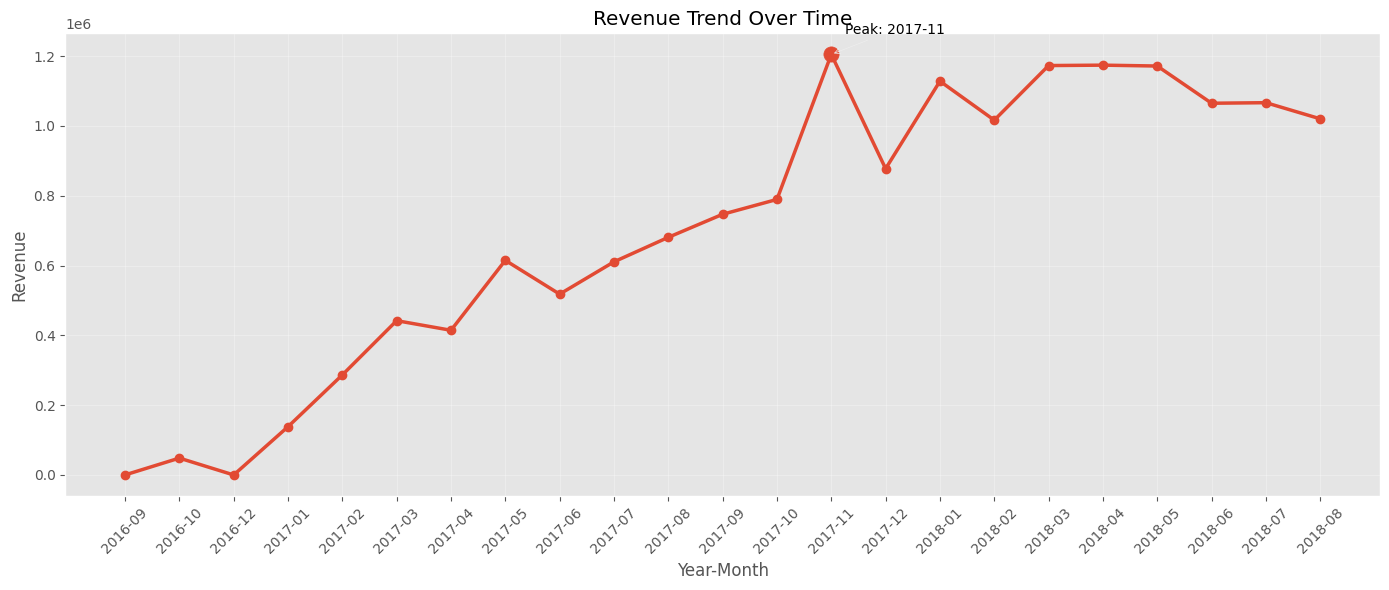

In [46]:
peak = monthly_trend.loc[
    monthly_trend["total_sales"].idxmax()
]

plt.figure(figsize=(14,6))

plt.plot(
    monthly_trend["year_month"],
    monthly_trend["total_sales"],
    marker="o",
    linewidth=2.5
)

plt.scatter(
    peak["year_month"],
    peak["total_sales"],
    s=120
)

plt.annotate(
    f'Peak: {peak["year_month"]}',
    xy=(peak["year_month"], peak["total_sales"]),
    xytext=(10, 15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Revenue Trend Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Business Insight

The revenue trend demonstrates a strong and consistent business growth throughout the observed period.

Revenue increased steadily during 2017, reaching its highest point in **November 2017**, indicating a significant increase in customer purchasing activity. This peak may be associated with seasonal shopping events or promotional campaigns.

Following a temporary decline in December 2017, revenue recovered and remained consistently above **1 million** from **March to August 2018**, suggesting stable business performance and sustained customer demand.

Overall, the trend indicates that the company experienced continuous sales growth with no prolonged periods of declining revenue during the available observation period.

### Business Recommendation

Based on the revenue trend analysis, the following recommendations are proposed:

- Analyze the business strategies and promotional activities implemented during **November 2017**, as this period generated the highest revenue and may provide valuable insights for future campaigns.

- Prepare inventory and logistics capacity ahead of historically high-performing periods to ensure product availability and maintain customer satisfaction.

- Maintain consistent marketing efforts throughout the year to sustain the stable revenue observed during 2018.

- Continue monitoring monthly sales trends to support demand forecasting and improve inventory planning for future business operations.

# Business Question 4

## Which payment methods are most frequently used?

Understanding customer payment preferences helps businesses optimize payment services, design promotional campaigns, and improve the checkout experience.

In [47]:
payment_summary = (
    sales.groupby("payment_type")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

payment_summary.columns = [
    "Payment Method",
    "Number of Orders"
]

payment_summary

,Payment Method,Number of Orders
0,credit_card,76505
1,boleto,19784
2,voucher,3866
3,debit_card,1528
4,not_defined,3


In [48]:
total_orders = payment_summary["Number of Orders"].sum()

payment_summary["Contribution (%)"] = (
    payment_summary["Number of Orders"]
    / total_orders
    *100
).round(2)

payment_summary

,Payment Method,Number of Orders,Contribution (%)
0,credit_card,76505,75.24
1,boleto,19784,19.46
2,voucher,3866,3.80
3,debit_card,1528,1.50
4,not_defined,3,0.00


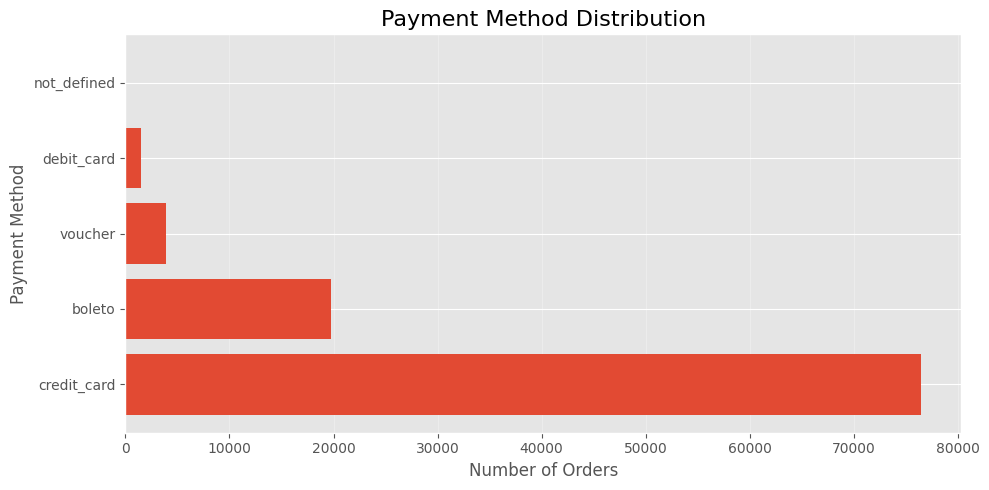

In [49]:
plt.figure(figsize=(10,5))

plt.barh(
    payment_summary["Payment Method"],
    payment_summary["Number of Orders"]
)

plt.title(
    "Payment Method Distribution",
    fontsize=16
)

plt.xlabel("Number of Orders")
plt.ylabel("Payment Method")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

In [50]:
payment_summary.sort_values(
    "Number of Orders",
    ascending=False
)

,Payment Method,Number of Orders,Contribution (%)
0,credit_card,76505,75.24
1,boleto,19784,19.46
2,voucher,3866,3.80
3,debit_card,1528,1.50
4,not_defined,3,0.00


### Business Insight

The payment method analysis reveals that **credit cards** are the dominant payment option, accounting for **76,505 orders (75.24%)** of all transactions. This indicates that customers strongly prefer credit card payments when shopping on the platform.

The second most popular payment method is **boleto**, contributing **19,784 orders (19.46%)**, while **voucher** and **debit card** account for only **3.80%** and **1.50%**, respectively.

The **not_defined** payment type appears only **3 times**, representing a negligible portion of the dataset and likely indicating missing or incomplete transaction records.

Overall, the payment distribution shows a heavy reliance on credit card transactions, suggesting that payment convenience and installment options may significantly influence customer purchasing behavior.

### Business Recommendation

Based on the payment method analysis, the following recommendations are proposed:

- Continue optimizing the credit card payment experience, as it is the preferred payment method for more than **75%** of customers.

- Collaborate with banks and payment providers to offer installment plans, cashback, and exclusive promotions for credit card users to encourage higher purchase values.

- Maintain support for **boleto**, as it remains the second most popular payment method and serves customers who prefer non-card transactions.

- Investigate the **not_defined** payment records to improve data quality and ensure accurate transaction reporting.

- Monitor payment method trends regularly to identify shifts in customer preferences and adapt payment strategies accordingly.

In [51]:
credit_card = sales[
    sales["payment_type"] == "credit_card"
]

installment = (
    credit_card["payment_installments"]
    .value_counts()
    .sort_index()
)

installment

payment_installments
0.0         3
1.0     28082
2.0     13838
3.0     11889
4.0      8072
5.0      6097
6.0      4674
7.0      1848
8.0      5120
9.0       739
10.0     6976
11.0       26
12.0      168
13.0       19
14.0       16
15.0       93
16.0        7
17.0        8
18.0       38
20.0       21
21.0        6
22.0        1
23.0        1
24.0       34
Name: count, dtype: int64

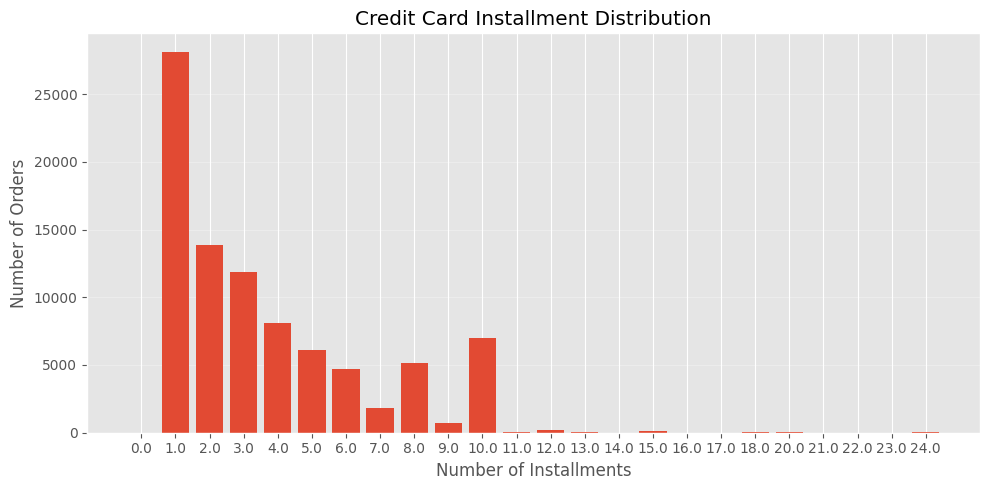

In [52]:
plt.figure(figsize=(10,5))

plt.bar(
    installment.index.astype(str),
    installment.values
)

plt.title("Credit Card Installment Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Number of Orders")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

The installment analysis shows that **single-payment (1 installment)** is the most preferred option, accounting for **28,082 credit card transactions**. This indicates that most customers prefer to pay their purchases in full rather than spreading payments over multiple installments.

Among installment plans, **2 installments (13,838 orders)** and **3 installments (11,889 orders)** are also widely used, suggesting that short-term financing is attractive for medium-value purchases.

Although customers can choose up to **24 installments**, the usage of installment plans longer than **10 months** is extremely low. This indicates that long-term installment options contribute only a small portion of total credit card transactions.

Overall, customer payment behavior suggests a strong preference for immediate or short-term payments while maintaining flexibility for higher-value purchases through limited installment plans.

### Business Recommendation

Based on the installment analysis, the following recommendations are proposed:

- Continue offering **1–3 installment options**, as these represent the majority of customer payment preferences.

- Promote installment plans for higher-priced products to encourage larger purchase values without significantly increasing customer financial burden.

- Evaluate the necessity of offering installment options beyond **12 months**, as their usage is extremely limited and may add unnecessary operational complexity.

- Collaborate with financial institutions to provide attractive installment promotions, such as **0% interest** or cashback offers, particularly for the most frequently selected installment periods.

# Business Question 5

## How long does order delivery take on average?

Delivery performance is one of the key factors affecting customer satisfaction. This analysis measures the average delivery time and examines the distribution of delivery durations.

In [65]:
delivery = (
    sales[sales["order_status"] == "delivered"]
    .drop_duplicates(subset="order_id")
    .copy()
)

In [66]:
delivery["delivery_days"] = (
    pd.to_datetime(delivery["order_delivered_customer_date"])
    -
    pd.to_datetime(delivery["order_purchase_timestamp"])
).dt.days

In [67]:
delivery["delivery_days"].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

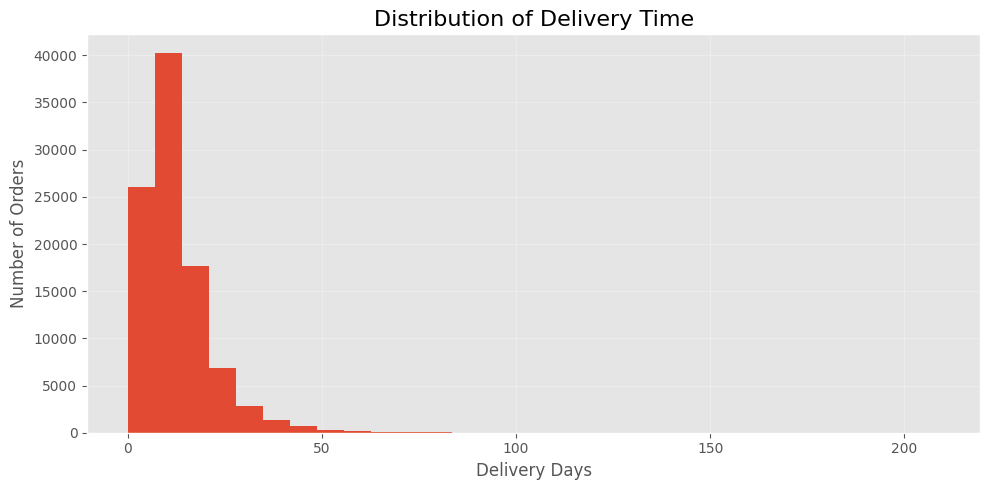

In [68]:
plt.figure(figsize=(10,5))

plt.hist(
    delivery["delivery_days"],
    bins=30
)

plt.title(
    "Distribution of Delivery Time",
    fontsize=16
)

plt.xlabel("Delivery Days")

plt.ylabel("Number of Orders")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [69]:
avg_delivery = delivery["delivery_days"].mean()

print(
    f"Average Delivery Time: {avg_delivery:.2f} days"
)

Average Delivery Time: 12.09 days


In [70]:
delivery["delivery_days"].median()

np.float64(10.0)

In [71]:
delivery["late_delivery"] = (
    pd.to_datetime(
        delivery["order_delivered_customer_date"]
    )
    >
    pd.to_datetime(
        delivery["order_estimated_delivery_date"]
    )
)

In [72]:
late_summary = (
    delivery["late_delivery"]
    .value_counts()
    .rename(
        {
            True:"Late",
            False:"On Time"
        }
    )
)

late_summary

late_delivery
On Time    88652
Late        7826
Name: count, dtype: int64

In [73]:
(
    late_summary
    /
    late_summary.sum()
    *100
).round(2)

late_delivery
On Time    91.89
Late        8.11
Name: count, dtype: float64

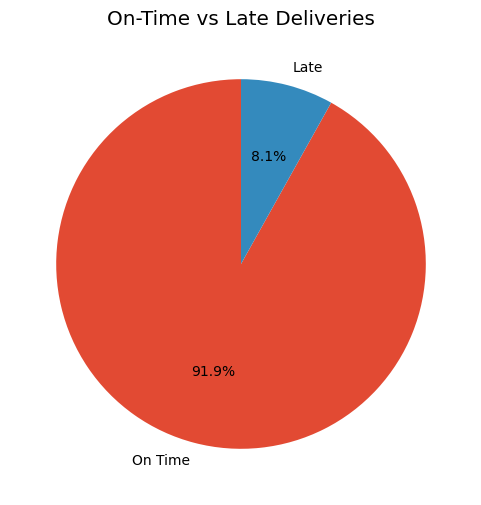

In [74]:
plt.figure(figsize=(6,6))

plt.pie(
    late_summary.values,
    labels=late_summary.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "On-Time vs Late Deliveries"
)

plt.show()

### Business Insight

The delivery performance analysis shows that completed orders are delivered in an average of **12.09 days**, while the median delivery time is **10 days**.

Approximately **50%** of all delivered orders arrive within **10 days**, and **75%** are delivered within **15 days**, indicating that most customers receive their orders within two weeks.

The delivery time distribution is **right-skewed**, meaning that although the majority of orders are delivered relatively quickly, a small number of deliveries experience significantly longer delivery times. The maximum recorded delivery time reaches **209 days**, suggesting the presence of exceptional operational cases or extreme outliers.

Furthermore, **91.89%** of all delivered orders arrived **on or before the estimated delivery date**, while only **8.11%** were delivered late. This demonstrates a high level of delivery reliability and consistent logistics performance.

### Business Recommendation

Based on the delivery performance analysis, the following recommendations are proposed:

- Maintain the current logistics strategy, as more than **91%** of orders are delivered on time.

- Investigate the root causes of the **8.11%** late deliveries by analyzing carrier performance, warehouse operations, and regional delivery routes.

- Review extreme delivery cases (e.g., deliveries exceeding 60 days) to determine whether they are caused by operational issues or data quality problems.

- Continue monitoring delivery performance as a key operational KPI because timely deliveries directly influence customer satisfaction and business reputation.

In [75]:
review_delivery = (
    delivery.groupby("late_delivery")["review_score"]
    .mean()
    .reset_index()
)

review_delivery["late_delivery"] = review_delivery[
    "late_delivery"
].replace({
    False: "On Time",
    True: "Late"
})

review_delivery

,late_delivery,review_score
0,On Time,4.294519
1,Late,2.565461


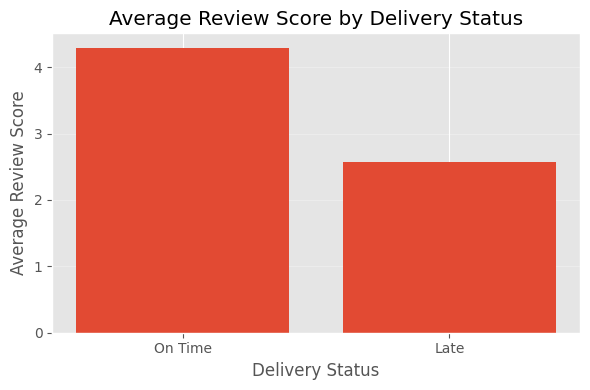

In [76]:
plt.figure(figsize=(6,4))

plt.bar(
    review_delivery["late_delivery"],
    review_delivery["review_score"]
)

plt.title("Average Review Score by Delivery Status")

plt.xlabel("Delivery Status")

plt.ylabel("Average Review Score")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

The analysis reveals a strong relationship between delivery performance and customer satisfaction.

Customers who received their orders **on time** gave an average review score of **4.29 out of 5**, indicating a high level of satisfaction with their shopping experience.

In contrast, customers whose orders were delivered **late** gave an average review score of only **2.57 out of 5**, representing a substantial decrease of approximately **40%** compared with on-time deliveries.

This result demonstrates that delivery reliability is one of the most influential factors affecting customer satisfaction. Delayed deliveries significantly increase the likelihood of negative customer reviews, which may ultimately impact brand reputation and customer retention.

### Business Recommendation

Based on the relationship between delivery performance and customer reviews, the following recommendations are proposed:

- Prioritize on-time delivery performance as a strategic business KPI because it has a direct impact on customer satisfaction.

- Monitor logistics partners regularly and identify regions or carriers with high late-delivery rates to improve operational efficiency.

- Implement proactive customer communication, such as delivery status notifications and delay alerts, to reduce customer frustration when delays occur.

- Consider offering compensation, discount vouchers, or loyalty rewards for significantly delayed orders to improve customer experience and encourage repeat purchases.